In [1]:
import polars as pl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import networkx as nx
from scipy.stats import chi2_contingency
sns.set_theme(style='whitegrid')
sns.set_palette('Dark2')

In [2]:
study_metadata = pl.read_csv('data/hmp2_metadata_2018-08-20.csv', schema_overrides={'External ID': pl.String}).filter(pl.col('data_type') == 'metagenomics')
study_metadata = study_metadata.select(['External ID', 'Age at diagnosis', 'consent_age', 'sex', 'diagnosis']).with_columns(pl.col("External ID").str.split("_").list.get(0).alias("External ID"))
study_metadata

External ID,Age at diagnosis,consent_age,sex,diagnosis
str,f64,f64,str,str
"""CSM5FZ3N""",28.0,43.0,"""Female""","""CD"""
"""CSM5FZ3R""",28.0,43.0,"""Female""","""CD"""
"""CSM5YRY7""",28.0,43.0,"""Female""","""CD"""
"""CSM5FZ3V""",28.0,43.0,"""Female""","""CD"""
"""CSM5FZ4C""",28.0,43.0,"""Female""","""CD"""
…,…,…,…,…
"""PSMA26A1""",8.0,16.0,"""Female""","""UC"""
"""PSMA26A3""",8.0,16.0,"""Female""","""UC"""
"""PSMB4MC1""",8.0,16.0,"""Female""","""UC"""


In [3]:
ena_metadata = pl.read_csv('data/filereport_read_run_PRJNA398089.tsv', separator='\t').select(['sample_accession', 'experiment_alias'])
ena_metadata = ena_metadata.with_columns(pl.col("experiment_alias").str.split("_").list.get(0).alias("experiment_alias")).join(study_metadata, left_on='experiment_alias', right_on='External ID')

In [4]:
genome_metadata = pl.read_csv('https://swifter.embl.de/~fullam/spire/metadata/spire_v1_genome_metadata.tsv.gz', separator='\t')
genome_metadata = genome_metadata.select(['genome_id', 'domain', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'derived_from_sample', 'n_contigs'])
genome_metadata

genome_id,domain,phylum,class,order,family,genus,species,derived_from_sample,n_contigs
str,str,str,str,str,str,str,str,str,f64
"""spire_mag_00000001""","""Bacteria""","""Actinobacteriota""","""Actinomycetia""","""Actinomycetales""","""Microbacteriaceae""","""Pontimonas""","""Pontimonas sp001438965""","""SAMEA104408696""",153.0
"""spire_mag_00000003""","""Bacteria""","""Proteobacteria""","""Alphaproteobacteria""","""Pelagibacterales""","""Pelagibacteraceae""","""Pelagibacter""","""Pelagibacter sp013204495""","""SAMEA104408696""",124.0
"""spire_mag_00000006""","""Bacteria""","""Chloroflexota""","""Dehalococcoidia""","""UBA1151""","""UBA1328""","""UBA1328""",null,"""SAMEA104408696""",317.0
"""spire_mag_00000007""","""Bacteria""","""Planctomycetota""","""Planctomycetia""","""Planctomycetales""","""Planctomycetaceae""",null,null,"""SAMEA104408696""",813.0
"""spire_mag_00000008""","""Bacteria""","""Planctomycetota""","""UBA8108""","""UBA1146""","""UBA1146""","""JAFMMO01""",null,"""SAMEA104408696""",704.0
…,…,…,…,…,…,…,…,…,…
"""spire_mag_03023324""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Clostridium_Q""","""Clostridium_Q fessum""","""SAMEA14100596""",127.0
"""spire_mag_03023325""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Oscillospirales""","""Oscillospiraceae""","""ER4""","""ER4 sp000765235""","""SAMEA14100468""",34.0
"""spire_mag_03023326""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Agathobacter""","""Agathobacter rectalis""","""SAMEA14101339""",181.0


In [5]:
genome_metadata = genome_metadata.join(ena_metadata, left_on='derived_from_sample', right_on='sample_accession')
genome_metadata

genome_id,domain,phylum,class,order,family,genus,species,derived_from_sample,n_contigs,experiment_alias,Age at diagnosis,consent_age,sex,diagnosis
str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str
"""spire_mag_00360916""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Escherichia""","""Escherichia coli""","""SAMN07521601""",595.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360924""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07521601""",67.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360925""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Phocaeicola""","""Phocaeicola vulgatus""","""SAMN07521601""",86.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360930""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Pasteurellaceae""","""Haemophilus_D""","""Haemophilus_D sp001815355""","""SAMN07521700""",316.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
"""spire_mag_00360931""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Burkholderiales""","""Burkholderiaceae""","""Sutterella""","""Sutterella wadsworthensis_A""","""SAMN07521700""",76.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""spire_mag_02048099""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07532854""",66.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048102""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides finegoldii""","""SAMN07532854""",166.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048110""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Agathobacter""","""Agathobacter faecis""","""SAMN07521692""",53.0,"""CSM67U9B""",30.0,37.0,"""Female""","""CD"""


In [6]:
classifications = pl.read_csv('../results/functional_roles.tsv', separator='\t')
classifications

taxon,exchange_tendency,cooperation_alignment,provisioning_bias,interaction_synergy,functional_role
str,str,str,str,str,str
"""spire_mag_00375920""","""Mixed""","""Low""","""Receiver""","""Passive""","""MLRP"""
"""spire_mag_00362780""","""Mixed""","""High""","""Provider""","""Primary""","""MHPP"""
"""spire_mag_00373296""","""Consumer""","""Low""","""Receiver""","""Passive""","""CLRP"""
"""spire_mag_00369020""","""Mixed""","""High""","""Provider""","""Primary""","""MHPP"""
"""spire_mag_00366726""","""Mixed""","""Low""","""Receiver""","""Passive""","""MLRP"""
…,…,…,…,…,…
"""spire_mag_00370395""","""Consumer""","""Low""","""Receiver""","""Passive""","""CLRP"""
"""spire_mag_00363470""","""Consumer""","""Low""","""Receiver""","""Passive""","""CLRP"""
"""spire_mag_00368645""","""Producer""","""High""","""Provider""","""Primary""","""PHPP"""


In [7]:
joined = classifications.join(genome_metadata, left_on='taxon', right_on='genome_id')
joined

taxon,exchange_tendency,cooperation_alignment,provisioning_bias,interaction_synergy,functional_role,domain,phylum,class,order,family,genus,species,derived_from_sample,n_contigs,experiment_alias,Age at diagnosis,consent_age,sex,diagnosis
str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str
"""spire_mag_00360916""","""Consumer""","""High""","""Receiver""","""Dependent""","""CHRD""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Escherichia""","""Escherichia coli""","""SAMN07521601""",595.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360924""","""Producer""","""Low""","""Receiver""","""Passive""","""PLRP""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07521601""",67.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360925""","""Producer""","""High""","""Provider""","""Primary""","""PHPP""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Phocaeicola""","""Phocaeicola vulgatus""","""SAMN07521601""",86.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360930""","""Mixed""","""Low""","""Receiver""","""Passive""","""MLRP""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Pasteurellaceae""","""Haemophilus_D""","""Haemophilus_D sp001815355""","""SAMN07521700""",316.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
"""spire_mag_00360931""","""Producer""","""High""","""Receiver""","""Dependent""","""PHRD""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Burkholderiales""","""Burkholderiaceae""","""Sutterella""","""Sutterella wadsworthensis_A""","""SAMN07521700""",76.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""spire_mag_02048099""","""Mixed""","""Low""","""Provider""","""Marginal""","""MLPM""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07532854""",66.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048102""","""Mixed""","""Low""","""Receiver""","""Passive""","""MLRP""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides finegoldii""","""SAMN07532854""",166.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048110""","""Mixed""","""Low""","""Receiver""","""Passive""","""MLRP""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Agathobacter""","""Agathobacter faecis""","""SAMN07521692""",53.0,"""CSM67U9B""",30.0,37.0,"""Female""","""CD"""


In [8]:
df = joined.select(['exchange_tendency',	'cooperation_alignment',	'provisioning_bias',	'interaction_synergy',	'functional_role', 'diagnosis', 'species'])
df

exchange_tendency,cooperation_alignment,provisioning_bias,interaction_synergy,functional_role,diagnosis,species
str,str,str,str,str,str,str
"""Consumer""","""High""","""Receiver""","""Dependent""","""CHRD""","""nonIBD""","""Escherichia coli"""
"""Producer""","""Low""","""Receiver""","""Passive""","""PLRP""","""nonIBD""","""Bacteroides uniformis"""
"""Producer""","""High""","""Provider""","""Primary""","""PHPP""","""nonIBD""","""Phocaeicola vulgatus"""
"""Mixed""","""Low""","""Receiver""","""Passive""","""MLRP""","""CD""","""Haemophilus_D sp001815355"""
"""Producer""","""High""","""Receiver""","""Dependent""","""PHRD""","""CD""","""Sutterella wadsworthensis_A"""
…,…,…,…,…,…,…
"""Mixed""","""Low""","""Provider""","""Marginal""","""MLPM""","""UC""","""Bacteroides uniformis"""
"""Mixed""","""Low""","""Receiver""","""Passive""","""MLRP""","""UC""","""Bacteroides finegoldii"""
"""Mixed""","""Low""","""Receiver""","""Passive""","""MLRP""","""CD""","""Agathobacter faecis"""


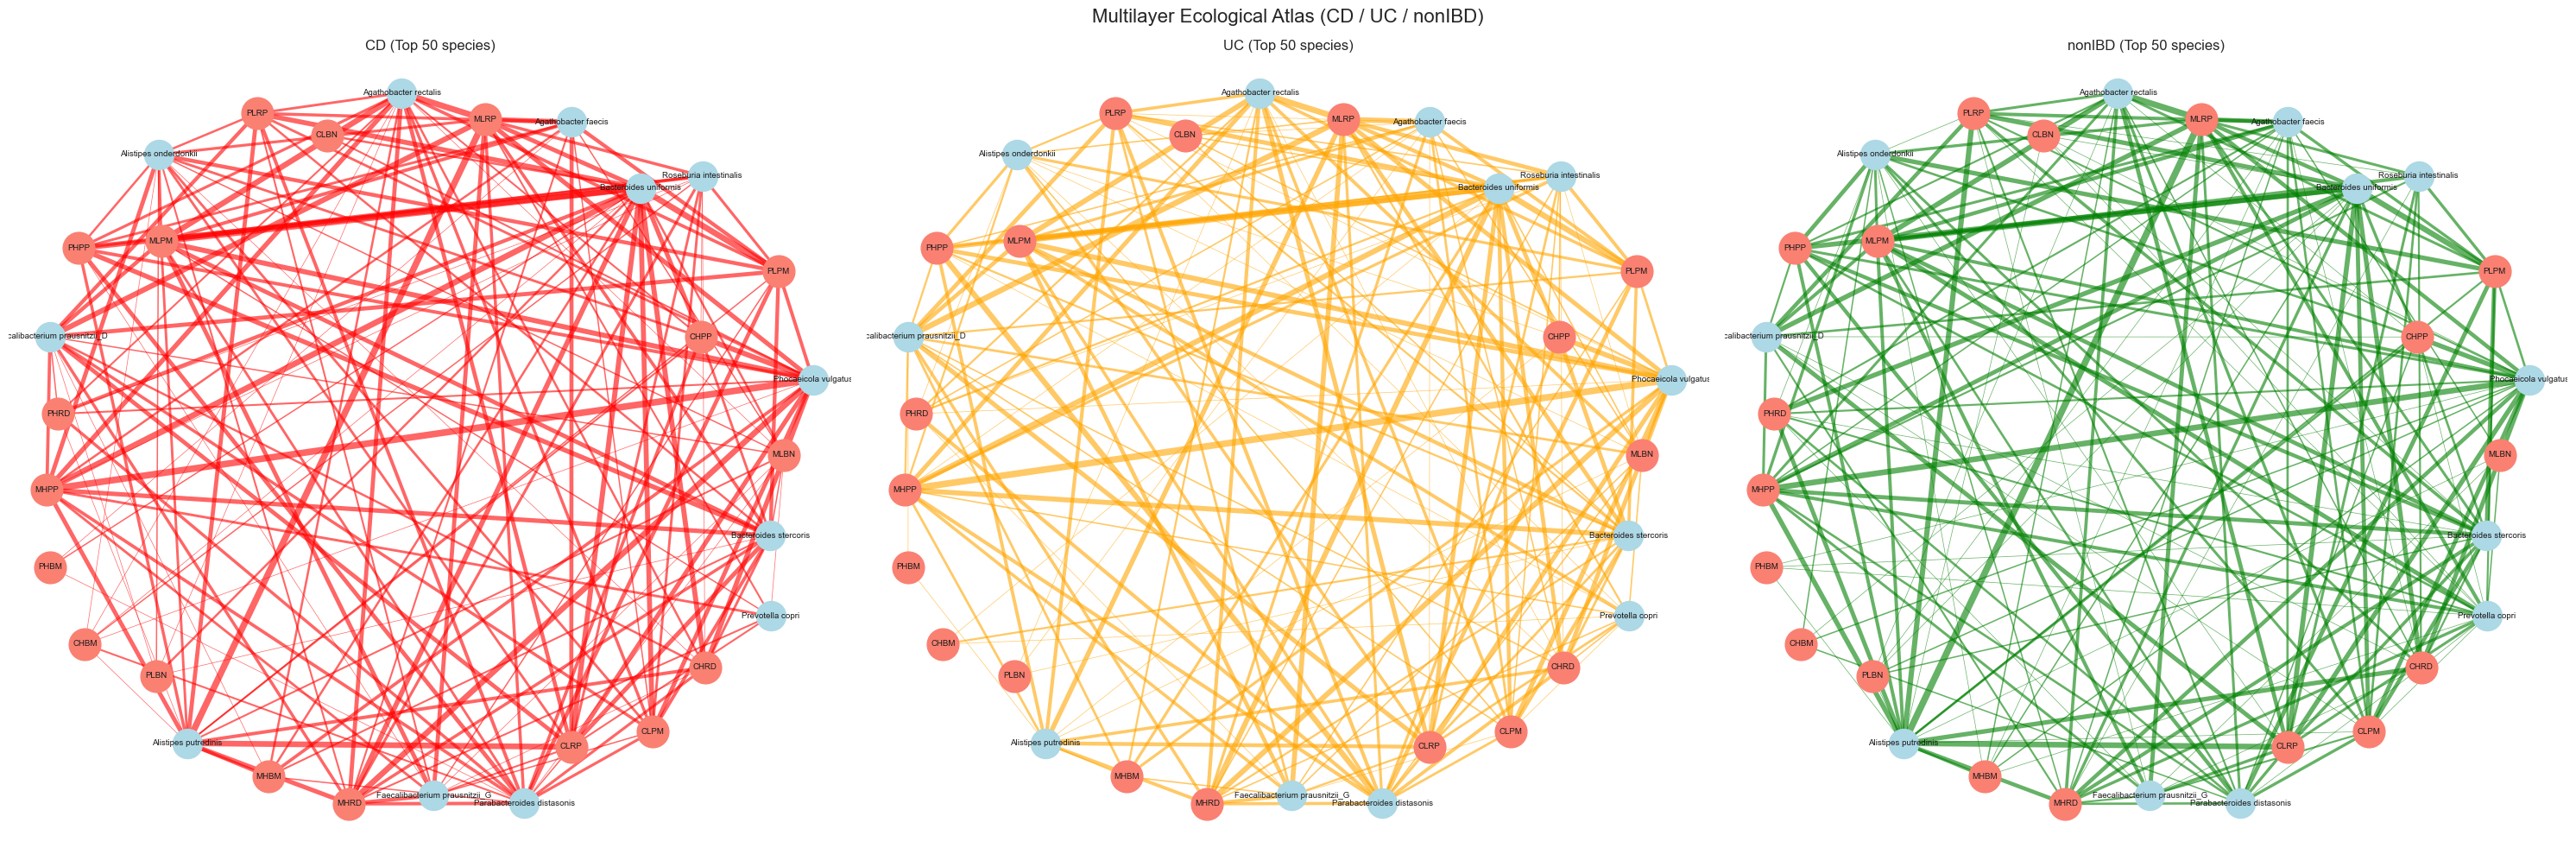

In [9]:
# ------------------------------------------------------------
# 1. CLEAN + AGGREGATE
# ------------------------------------------------------------

edges = (
    df.drop_nulls(subset=["species", "functional_role", "diagnosis"])
      .group_by(["species", "functional_role", "diagnosis"])
      .len()
      .rename({"len": "weight"})
)

edges = edges.with_columns([
    pl.col("weight").alias("weight_raw"),
    (pl.col("weight") / pl.sum("weight").over("diagnosis")).alias("weight_norm"),
    (pl.col("weight").log1p()).alias("weight_log")
])

pdf = edges.to_pandas()

# ------------------------------------------------------------
# 2. TOP 50 SPECIES PER DISEASE
# ------------------------------------------------------------

top_species = (
    pdf.groupby(["diagnosis", "species"])["weight_raw"]
       .sum()
       .reset_index()
       .sort_values(["diagnosis", "weight_raw"], ascending=[True, False])
       .groupby("diagnosis")
       .head(10)
)

allowed_species = set(top_species["species"])

pdf = pdf[pdf["species"].isin(allowed_species)]

# ------------------------------------------------------------
# 3. BUILD MULTILAYER GRAPHS
# ------------------------------------------------------------

diseases = ["CD", "UC", "nonIBD"]
graphs = {}

for d in diseases:

    G = nx.Graph()
    sub = pdf[pdf["diagnosis"] == d]

    for row in sub.itertuples(index=False):
        G.add_edge(
            row.species,
            row.functional_role,
            weight=row.weight_log,
            weight_raw=row.weight_raw
        )

    graphs[d] = G

# ------------------------------------------------------------
# 4. GLOBAL LAYOUT (shared ecological space)
# ------------------------------------------------------------

all_nodes = set(pdf["species"]).union(set(pdf["functional_role"]))

H = nx.Graph()
H.add_nodes_from(all_nodes)

pos = nx.spring_layout(H, seed=42, k=0.8)

# ------------------------------------------------------------
# 5. PLOTTING (MULTILAYER ATLAS)
# ------------------------------------------------------------

colors = {
    "CD": "red",
    "UC": "orange",
    "nonIBD": "green"
}

fig, axes = plt.subplots(1, 3, figsize=(30, 10), sharex=True, sharey=True)

for ax, disease in zip(axes, diseases):

    G = graphs[disease]

    weights = [d["weight"] for _, _, d in G.edges(data=True)]
    max_w = max(weights) if weights else 1
    min_w = min(weights) if weights else 0

    # --------------------------------------------------------
    # EDGES (FIXED VISIBILITY SCALING)
    # --------------------------------------------------------

    for u, v, data in G.edges(data=True):

        if u not in pos or v not in pos:
            continue

        w = data["weight"]

        linewidth = 0.5 + 5 * (w - min_w) / (max_w - min_w + 1e-9)

        ax.plot(
            [pos[u][0], pos[v][0]],
            [pos[u][1], pos[v][1]],
            color=colors[disease],
            alpha=0.6,
            linewidth=linewidth
        )

    # --------------------------------------------------------
    # NODES
    # --------------------------------------------------------

    species_nodes = [n for n in G.nodes() if n in allowed_species]
    role_nodes = [n for n in G.nodes() if n not in species_nodes]

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=species_nodes,
        node_color="lightblue",
        node_size=600,
        ax=ax
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=role_nodes,
        node_color="salmon",
        node_size=700,
        ax=ax
    )

    nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)

    ax.set_title(f"{disease} (Top 50 species)")
    ax.axis("off")

plt.suptitle("Multilayer Ecological Atlas (CD / UC / nonIBD)", fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7818/1148618430.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


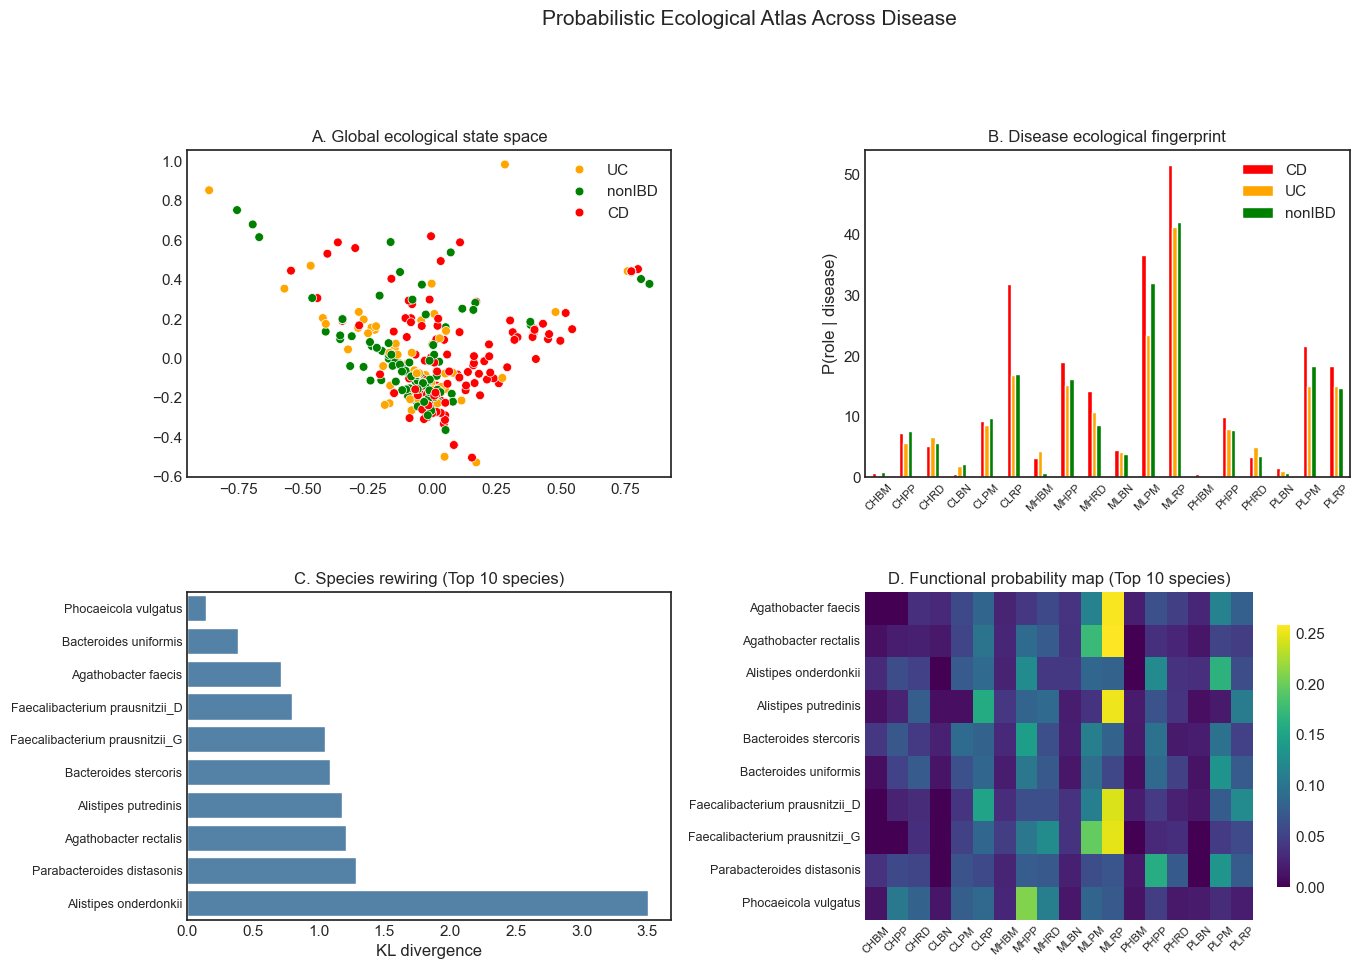

In [10]:
# ============================================================
# 1. PROBABILISTIC MODEL P(f | s, d)
# ============================================================

alpha = 1.0

counts = (
    df.drop_nulls(subset=["species", "functional_role", "diagnosis"])
      .group_by(["species", "diagnosis", "functional_role"])
      .len()
      .rename({"len": "n"})
)

pdf = counts.to_pandas()

rows = []

for (s, d), sub in pdf.groupby(["species", "diagnosis"]):

    total = sub["n"].sum()

    for _, r in sub.iterrows():

        p = (r["n"] + alpha) / (total + alpha * len(sub))

        rows.append({
            "species": s,
            "diagnosis": d,
            "functional_role": r["functional_role"],
            "p": p
        })

prob = pd.DataFrame(rows)

# ============================================================
# 2. TOP 10 SPECIES (GLOBAL RANKING)
# ============================================================

top_species = (
    pdf.groupby("species")["n"]
       .sum()
       .sort_values(ascending=False)
       .head(10)
       .index
)

# ============================================================
# 3. MATRICES
# ============================================================

pivot_all = prob.pivot_table(
    index="species",
    columns=["diagnosis", "functional_role"],
    values="p",
    fill_value=0
)

labels_all = (
    pdf.groupby("species")["diagnosis"]
      .agg(lambda x: x.value_counts().index[0])
      .reset_index()
)

# filtered version for bottom panels
prob_top = prob[prob["species"].isin(top_species)]

pivot_top = prob_top.pivot_table(
    index="species",
    columns=["functional_role"],
    values="p",
    fill_value=0
)

# ============================================================
# 4. FIGURE SETUP
# ============================================================

plt.style.use("seaborn-v0_8-white")

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, wspace=0.4, hspace=0.35)

# ============================================================
# A. GLOBAL ECOLOGICAL STATE SPACE (ALL SPECIES)
# ============================================================

ax1 = fig.add_subplot(gs[0, 0])

coords = PCA(n_components=2).fit_transform(pivot_all.values)

embed = pd.DataFrame(coords, columns=["PC1", "PC2"])
embed["species"] = pivot_all.index
embed = embed.merge(labels_all, on="species")

sns.scatterplot(
    data=embed,
    x="PC1",
    y="PC2",
    hue="diagnosis",
    ax=ax1,
    s=40,
    palette={"CD": "red", "UC": "orange", "nonIBD": "green"}
)

ax1.set_title("A. Global ecological state space")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.legend(frameon=False)

# ============================================================
# B. GLOBAL DISEASE FINGERPRINT (ALL DATA)
# ============================================================

ax2 = fig.add_subplot(gs[0, 1])

fp = (
    prob.groupby(["diagnosis", "functional_role"])["p"]
        .sum()
        .reset_index()
)

pivot_fp = fp.pivot(
    index="functional_role",
    columns="diagnosis",
    values="p"
).fillna(0)

pivot_fp.plot(
    kind="bar",
    ax=ax2,
    color=["red", "orange", "green"]
)

ax2.set_title("B. Disease ecological fingerprint")
ax2.set_xlabel("")
ax2.set_ylabel("P(role | disease)")

ax2.tick_params(axis="x", rotation=45, labelsize=8)
ax2.margins(x=0.02)
ax2.legend(frameon=False)

# ============================================================
# C. SPECIES REWIRING (TOP 10 ONLY)
# ============================================================

ax3 = fig.add_subplot(gs[1, 0])

def kl(p, q):
    p = np.array(p) + 1e-9
    q = np.array(q) + 1e-9
    return np.sum(p * np.log(p / q))

rewiring = []

for s in top_species:

    cd = prob[(prob.species == s) & (prob.diagnosis == "CD")]
    uc = prob[(prob.species == s) & (prob.diagnosis == "UC")]

    if len(cd) == 0 or len(uc) == 0:
        continue

    roles = sorted(set(cd.functional_role) | set(uc.functional_role))

    p_cd = cd.set_index("functional_role").reindex(roles)["p"].fillna(0).values
    p_uc = uc.set_index("functional_role").reindex(roles)["p"].fillna(0).values

    rewiring.append((s, kl(p_cd, p_uc)))

rw = pd.DataFrame(rewiring, columns=["species", "rewiring"])
rw = rw.sort_values("rewiring", ascending=True)

sns.barplot(
    data=rw,
    x="rewiring",
    y="species",
    ax=ax3,
    color="steelblue"
)

ax3.set_title("C. Species rewiring (Top 10 species)")
ax3.set_xlabel("KL divergence")
ax3.set_ylabel("")
ax3.tick_params(axis="y", labelsize=9)

# ============================================================
# D. FUNCTIONAL PROBABILITY MAP (TOP 10 ONLY)
# ============================================================

ax4 = fig.add_subplot(gs[1, 1])

heat = pivot_top.loc[pivot_top.index.intersection(top_species)]

sns.heatmap(
    heat,
    cmap="viridis",
    ax=ax4,
    cbar_kws={"shrink": 0.8}
)

ax4.set_title("D. Functional probability map (Top 10 species)")
ax4.set_xlabel("")
ax4.set_ylabel("")

ax4.tick_params(axis="y", labelsize=9)
ax4.tick_params(axis="x", rotation=45, labelsize=8)

# ============================================================
# FINAL TITLE
# ============================================================

fig.suptitle(
    "Probabilistic Ecological Atlas Across Disease",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7818/1670791265.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.96])


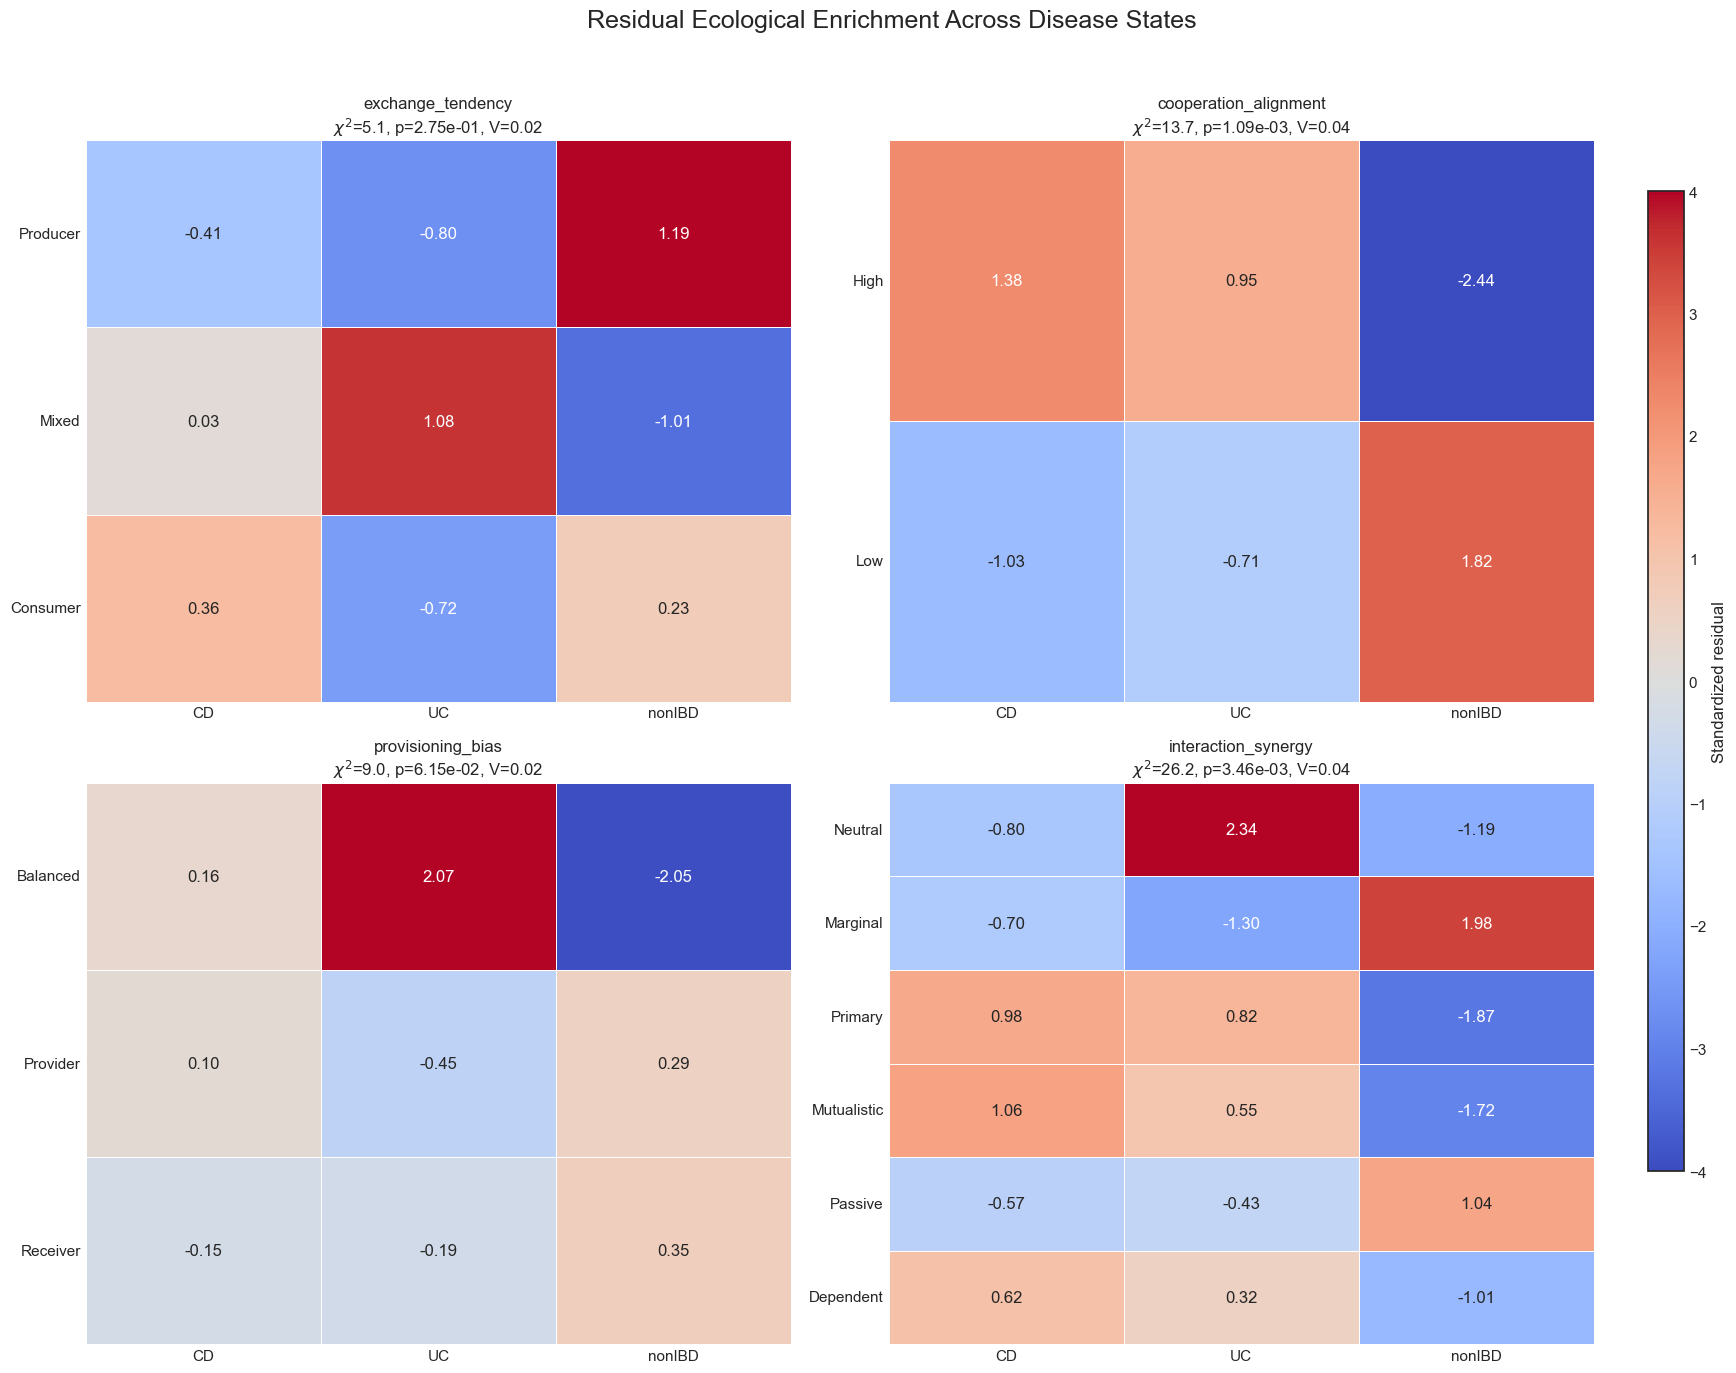

In [11]:
# ============================================================
# CLASSIFICATIONS TO ANALYZE
# ============================================================

classifications = [
    "exchange_tendency",
    "cooperation_alignment",
    "provisioning_bias",
    "interaction_synergy"
]

# ============================================================
# FIGURE SETUP
# ============================================================

plt.style.use("seaborn-v0_8-white")

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 14)
)

axes = axes.flatten()

# ============================================================
# LOOP THROUGH CLASSIFICATIONS
# ============================================================

for ax, cls in zip(axes, classifications):

    # --------------------------------------------------------
    # CONTINGENCY TABLE
    # --------------------------------------------------------

    table = pd.crosstab(
        df[cls],
        df["diagnosis"]
    )

    # --------------------------------------------------------
    # CHI-SQUARE + EXPECTED
    # --------------------------------------------------------

    chi2, p, dof, expected = chi2_contingency(table)

    expected = pd.DataFrame(
        expected,
        index=table.index,
        columns=table.columns
    )

    # --------------------------------------------------------
    # STANDARDIZED PEARSON RESIDUALS
    # --------------------------------------------------------

    residuals = (table - expected) / np.sqrt(expected)

    # --------------------------------------------------------
    # SORT BY SIGNAL STRENGTH
    # --------------------------------------------------------

    order = (
        residuals.abs()
                 .max(axis=1)
                 .sort_values(ascending=False)
                 .index
    )

    residuals = residuals.loc[order]

    # --------------------------------------------------------
    # HEATMAP
    # --------------------------------------------------------

    sns.heatmap(
        residuals,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        cbar=False,
        ax=ax
    )

    # --------------------------------------------------------
    # EFFECT SIZE (CRAMER'S V)
    # --------------------------------------------------------

    n = table.values.sum()

    cramers_v = np.sqrt(
        chi2 / (n * (min(table.shape) - 1))
    )

    # --------------------------------------------------------
    # TITLES
    # --------------------------------------------------------

    ax.set_title(
        (
            f"{cls}\n"
            f"$\\chi^2$={chi2:.1f}, "
            f"p={p:.2e}, "
            f"V={cramers_v:.2f}"
        ),
        fontsize=12
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

# ============================================================
# GLOBAL COLORBAR
# ============================================================

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

norm = plt.Normalize(vmin=-4, vmax=4)
sm = plt.cm.ScalarMappable(
    cmap="coolwarm",
    norm=norm
)

sm.set_array([])

fig.colorbar(
    sm,
    cax=cbar_ax,
    label="Standardized residual"
)

# ============================================================
# FINAL TITLE
# ============================================================

fig.suptitle(
    "Residual Ecological Enrichment Across Disease States",
    fontsize=18,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()

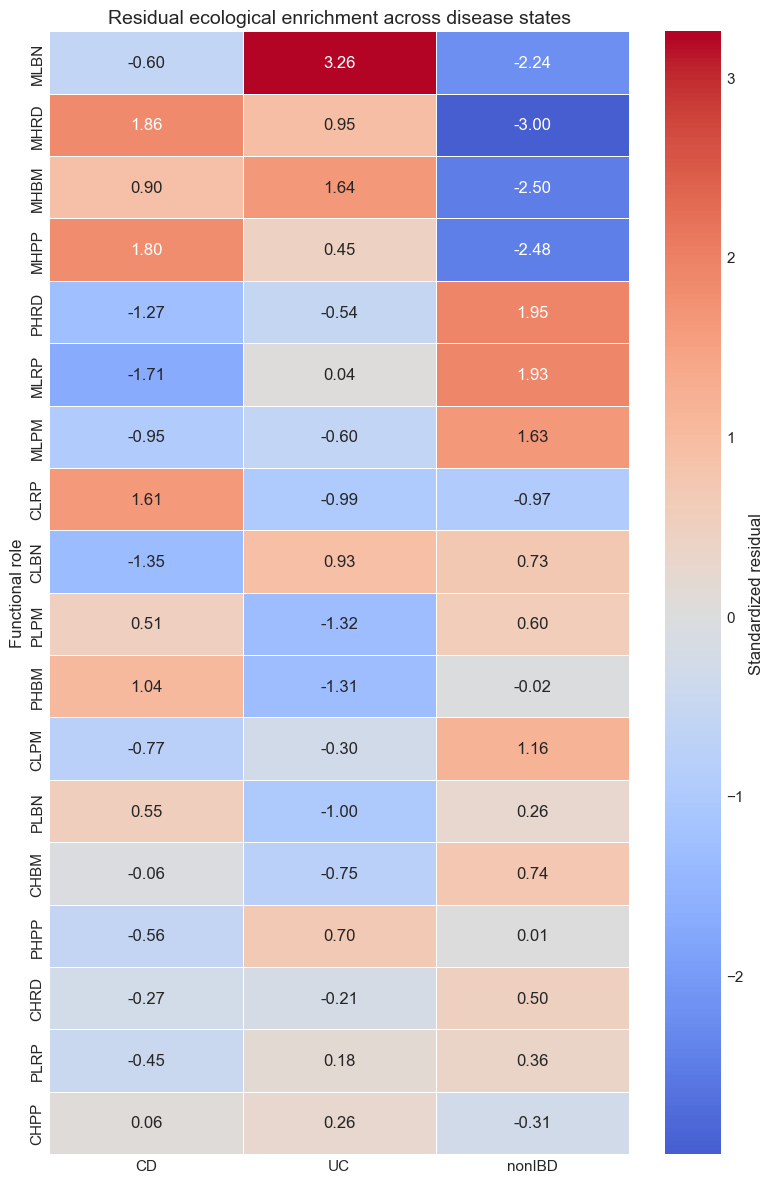


Chi-square test
----------------
chi2 = 84.010
p-value = 4.062e-06
dof = 34


In [12]:
# ============================================================
# CONTINGENCY TABLE
# ============================================================

table = pd.crosstab(
    df["functional_role"],
    df["diagnosis"]
)

# ============================================================
# CHI-SQUARE EXPECTED VALUES
# ============================================================

chi2, p, dof, expected = chi2_contingency(table)

expected = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

# ============================================================
# STANDARDIZED PEARSON RESIDUALS
# ============================================================

residuals = (table - expected) / np.sqrt(expected)

# ============================================================
# SORT ROLES BY MAX ABS SIGNAL
# ============================================================

order = (
    residuals.abs()
             .max(axis=1)
             .sort_values(ascending=False)
             .index
)

residuals = residuals.loc[order]

# ============================================================
# FIGURE
# ============================================================

plt.style.use("seaborn-v0_8-white")

fig, ax = plt.subplots(figsize=(8, 12))

sns.heatmap(
    residuals,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    cbar_kws={
        "label": "Standardized residual"
    },
    ax=ax
)

ax.set_title(
    "Residual ecological enrichment across disease states",
    fontsize=14
)

ax.set_xlabel("")
ax.set_ylabel("Functional role")

plt.tight_layout()
plt.show()

# ============================================================
# PRINT GLOBAL TEST
# ============================================================

print("\nChi-square test")
print("----------------")
print(f"chi2 = {chi2:.3f}")
print(f"p-value = {p:.3e}")
print(f"dof = {dof}")

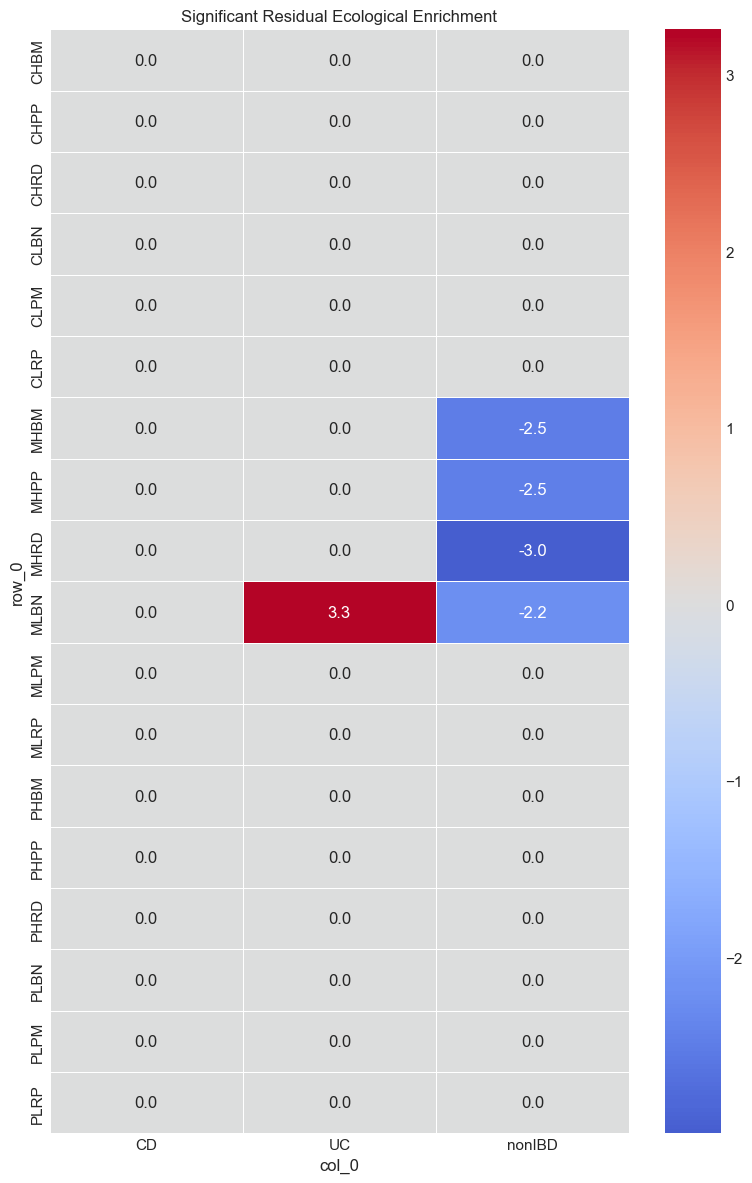

In [13]:

# ============================================================
# CONTINGENCY TABLE
# ============================================================

table = pd.crosstab(
    df["functional_role"],
    df["diagnosis"]
)

# ============================================================
# EXPECTED + RESIDUALS
# ============================================================

chi2, p, dof, expected = chi2_contingency(table)

expected = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

residuals = (table - expected) / np.sqrt(expected)

# ============================================================
# SIGNIFICANCE MASK
# ============================================================

masked = residuals.copy()

masked[np.abs(masked) < 2] = 0

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8, 12))

sns.heatmap(
    masked,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".1f"
)

plt.title(
    "Significant Residual Ecological Enrichment"
)

plt.tight_layout()
plt.show()

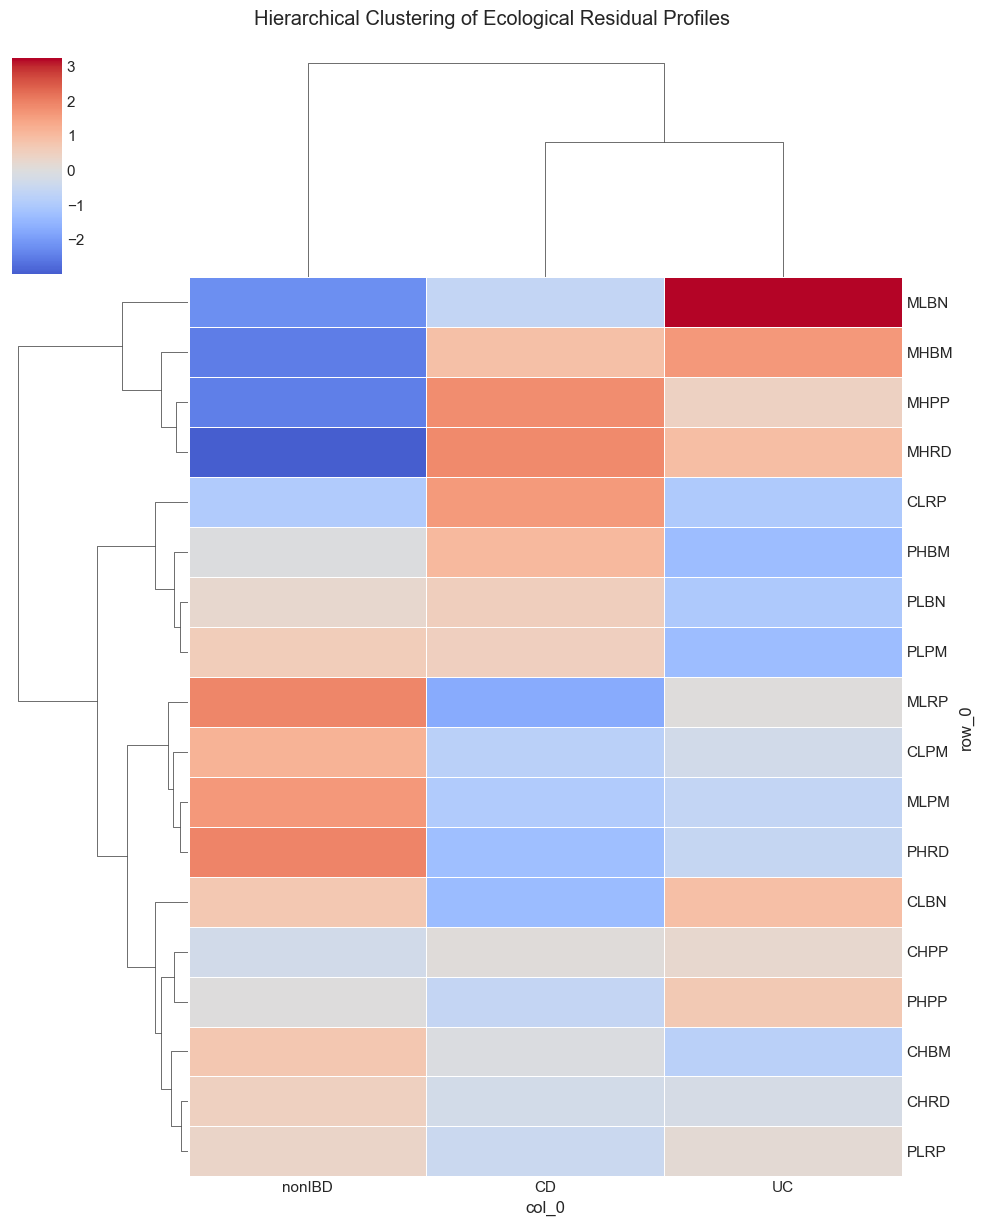

In [14]:
# ============================================================
# CLUSTERED RESIDUAL MAP
# ============================================================

sns.clustermap(
    residuals,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    figsize=(10, 12),
    metric="euclidean",
    method="ward"
)

plt.suptitle(
    "Hierarchical Clustering of Ecological Residual Profiles",
    y=1.02
)

plt.show()

In [15]:
roles = df["functional_role"].unique()

results = []

for role in roles:

    a = (
        ((df["functional_role"] == role) &
         (df["diagnosis"] == "CD")).sum()
    )

    b = (
        ((df["functional_role"] != role) &
         (df["diagnosis"] == "CD")).sum()
    )

    c = (
        ((df["functional_role"] == role) &
         (df["diagnosis"] == "nonIBD")).sum()
    )

    d = (
        ((df["functional_role"] != role) &
         (df["diagnosis"] == "nonIBD")).sum()
    )

    # Haldane correction
    or_value = (
        (a + 0.5) * (d + 0.5)
    ) / (
        (b + 0.5) * (c + 0.5)
    )

    results.append((role, or_value))

or_df = pd.DataFrame(
    results,
    columns=["functional_role", "odds_ratio"]
)

or_df = or_df.sort_values(
    "odds_ratio",
    ascending=False
)

print(or_df)

   functional_role  odds_ratio
1             MHBM    1.926704
7             MHRD    1.507264
0             MLBN    1.494353
6             MHPP    1.348062
16            PHBM    1.334993
11            CLRP    1.181217
14            PLBN    1.046018
17            CHPP    1.037588
3             PLPM    0.988055
5             PHPP    0.956684
9             PLRP    0.937811
10            CHRD    0.928224
12            MLPM    0.853934
2             CLPM    0.850362
8             MLRP    0.820670
4             CHBM    0.804937
13            PHRD    0.676259
15            CLBN    0.557753


In [16]:
roles = df["functional_role"].unique()

results = []

for role in roles:

    a = (
        ((df["functional_role"] == role) &
         (df["diagnosis"] == "UC")).sum()
    )

    b = (
        ((df["functional_role"] != role) &
         (df["diagnosis"] == "UC")).sum()
    )

    c = (
        ((df["functional_role"] == role) &
         (df["diagnosis"] == "nonIBD")).sum()
    )

    d = (
        ((df["functional_role"] != role) &
         (df["diagnosis"] == "nonIBD")).sum()
    )

    # Haldane correction
    or_value = (
        (a + 0.5) * (d + 0.5)
    ) / (
        (b + 0.5) * (c + 0.5)
    )

    results.append((role, or_value))

or_df = pd.DataFrame(
    results,
    columns=["functional_role", "odds_ratio"]
)

or_df = or_df.sort_values(
    "odds_ratio",
    ascending=False
)

print(or_df)

   functional_role  odds_ratio
13            MLBN    2.731026
1             MHBM    2.237325
11            MHRD    1.445701
9             MHPP    1.255685
8             CLBN    1.076926
14            PHPP    1.067897
6             CHPP    1.066770
10            CLRP    0.990526
16            PLRP    0.987074
4             CHRD    0.930951
2             MLRP    0.899244
5             CLPM    0.878367
0             MLPM    0.863611
15            PLPM    0.854653
17            PHRD    0.732128
3             PLBN    0.676330
7             CHBM    0.637856
12            PHBM    0.474663


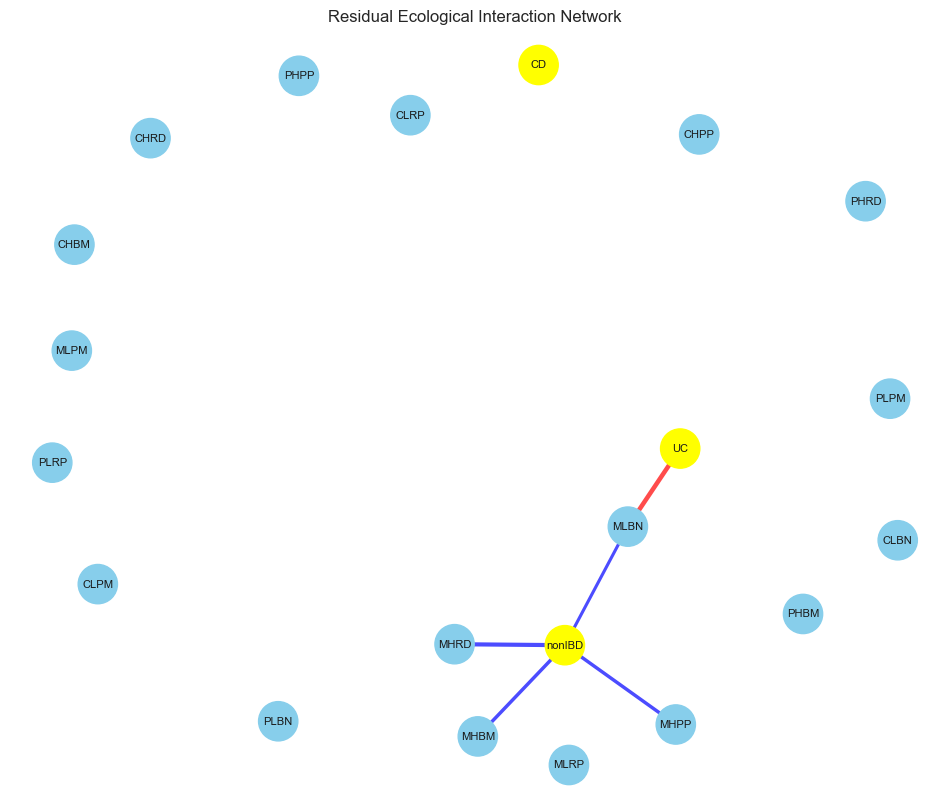

In [17]:
G = nx.Graph()

# add disease nodes
for d in residuals.columns:
    G.add_node(d, kind="disease")

# add role nodes
for r in residuals.index:
    G.add_node(r, kind="role")

# edges from significant residuals
for r in residuals.index:
    for d in residuals.columns:

        val = residuals.loc[r, d]

        if abs(val) >= 2:

            G.add_edge(
                r,
                d,
                weight=abs(val),
                sign=np.sign(val)
            )

# ============================================================
# LAYOUT
# ============================================================

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

plt.figure(figsize=(12, 10))

# node colors
node_colors = []

for n in G.nodes():

    if G.nodes[n]["kind"] == "disease":
        node_colors.append("yellow")
    else:
        node_colors.append("skyblue")

# edge colors
edge_colors = []

for u, v, data in G.edges(data=True):

    edge_colors.append(
        "red" if data["sign"] > 0 else "blue"
    )

# widths
widths = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=800
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    width=widths,
    alpha=0.7
)

plt.title(
    "Residual Ecological Interaction Network"
)

plt.axis("off")
plt.show()

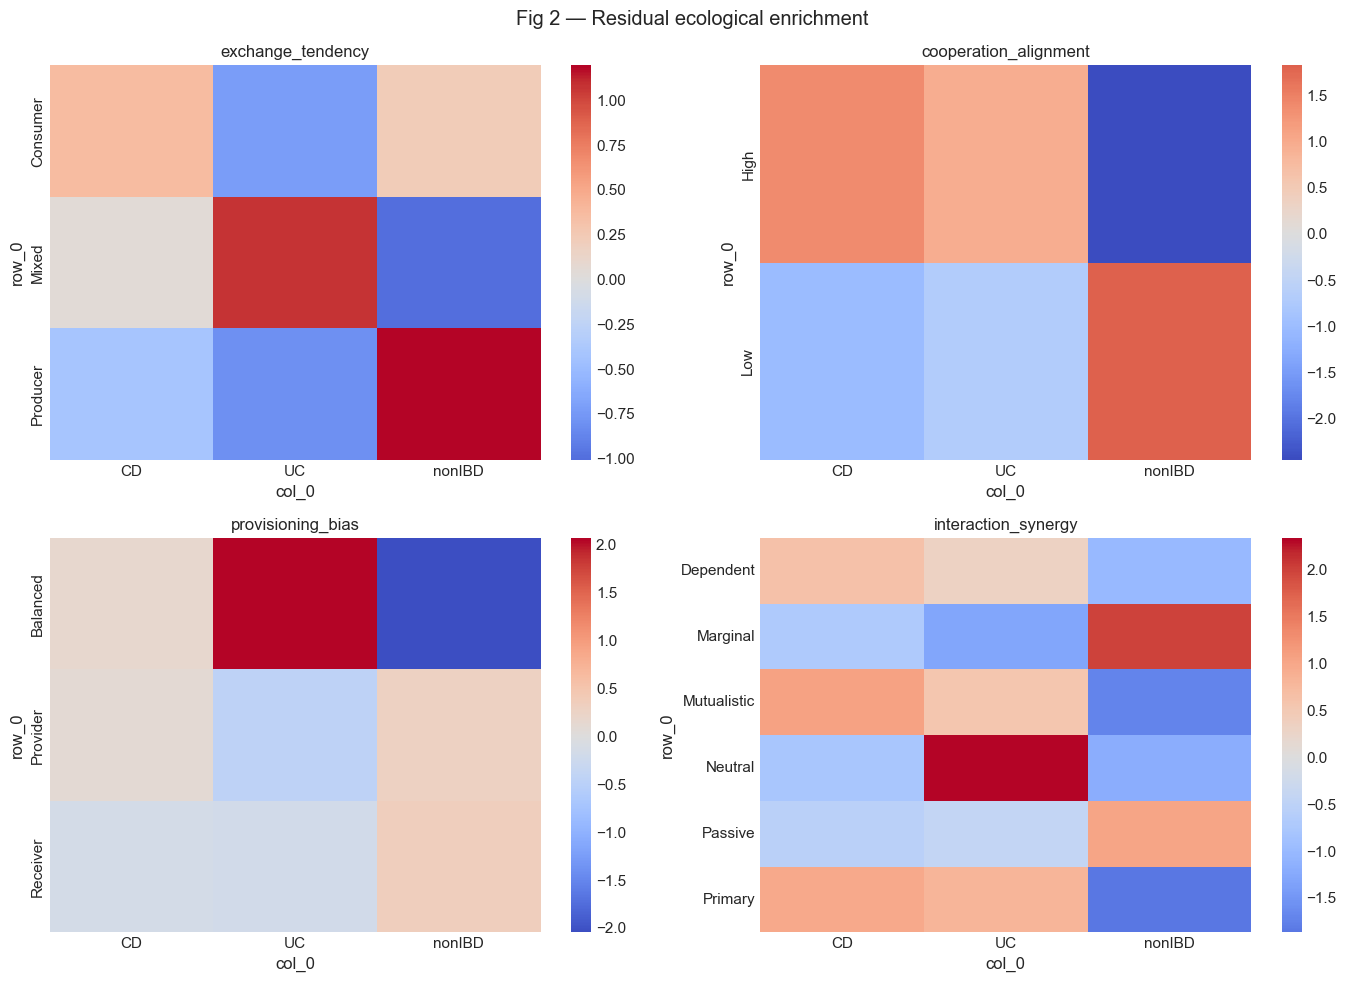

In [18]:
from scipy.stats import chi2_contingency

fig, axes = plt.subplots(2,2, figsize=(14,10))
axes = axes.flatten()

for i, cls in enumerate(classifications):

    table = pd.crosstab(df[cls], df["diagnosis"])
    chi2, p, dof, exp = chi2_contingency(table)

    exp = pd.DataFrame(exp, index=table.index, columns=table.columns)

    resid = (table - exp) / np.sqrt(exp)

    sns.heatmap(resid, cmap="coolwarm", center=0, ax=axes[i])

    axes[i].set_title(cls)

plt.suptitle("Fig 2 — Residual ecological enrichment")
plt.tight_layout()
plt.show()

In [23]:
df = df.to_pandas()
df

,exchange_tendency,cooperation_alignment,provisioning_bias,interaction_synergy,functional_role,diagnosis,species
0,Consumer,High,Receiver,Dependent,CHRD,nonIBD,Escherichia coli
1,Producer,Low,Receiver,Passive,PLRP,nonIBD,Bacteroides uniformis
2,Producer,High,Provider,Primary,PHPP,nonIBD,Phocaeicola vulgatus
3,Mixed,Low,Receiver,Passive,MLRP,CD,Haemophilus_D sp001815355
4,Producer,High,Receiver,Dependent,PHRD,CD,Sutterella wadsworthensis_A
...,...,...,...,...,...,...,...
7599,Mixed,Low,Provider,Marginal,MLPM,UC,Bacteroides uniformis
7600,Mixed,Low,Receiver,Passive,MLRP,UC,Bacteroides finegoldii
7601,Mixed,Low,Receiver,Passive,MLRP,CD,Agathobacter faecis
7602,Consumer,Low,Receiver,Passive,CLRP,nonIBD,Bacteroides fragilis


In [24]:
def kl(p, q):
    p = np.array(p)+1e-12
    q = np.array(q)+1e-12
    p/=p.sum(); q/=q.sum()
    return np.sum(p*np.log(p/q))

species_weights = df["species"].value_counts(normalize=True)

results = []



for cls in classifications:

    role_space = np.sort(
    pd.Series(df.loc[:, cls], dtype="string")
      .dropna()
      .unique()
    )

    base = df[df["diagnosis"]=="nonIBD"][cls].value_counts(normalize=True)
    base = np.array([base.get(r,0) for r in role_space])

    for s in df["species"].unique():

        sub = df[df["species"]==s]
        if len(sub)<10:
            continue

        uc = sub[sub["diagnosis"]=="UC"][cls].value_counts(normalize=True)
        cd = sub[sub["diagnosis"]=="CD"][cls].value_counts(normalize=True)

        def vec(d):
            return np.array([d.get(r,0) for r in role_space])

        results.append({
            "species": s,
            "cls": cls,
            "UC": species_weights[s]*kl(base, vec(uc)),
            "CD": species_weights[s]*kl(base, vec(cd))
        })

res = pd.DataFrame(results)

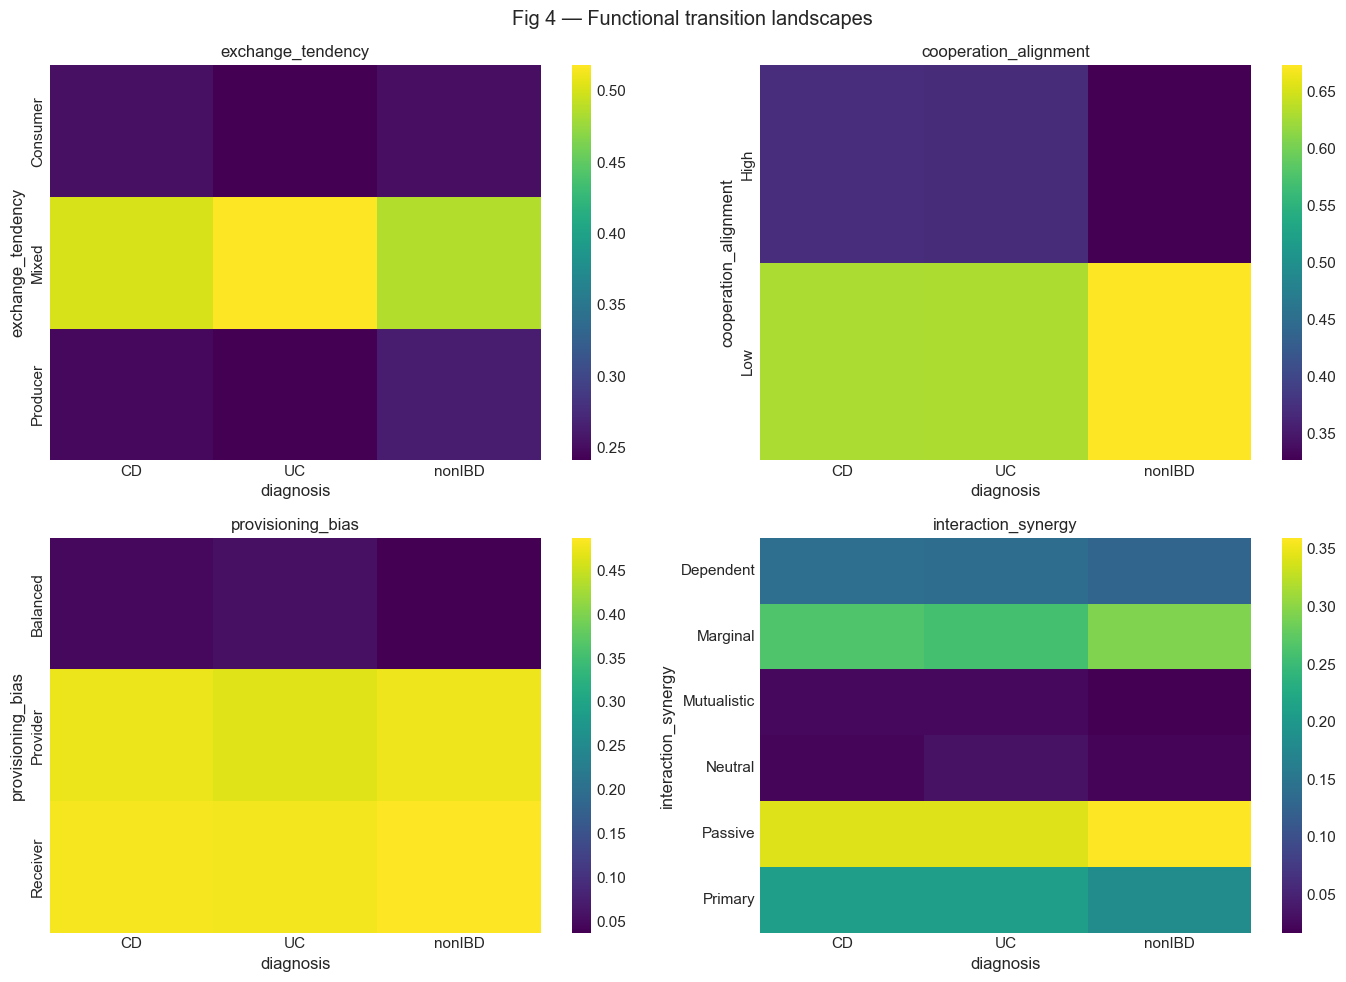

In [26]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
axes = axes.flatten()

for i, cls in enumerate(classifications):

    table = pd.crosstab(df[cls], df["diagnosis"])
    probs = table.div(table.sum(axis=0), axis=1)

    sns.heatmap(probs, cmap="viridis", ax=axes[i])

    axes[i].set_title(cls)

plt.suptitle("Fig 4 — Functional transition landscapes")
plt.tight_layout()
plt.show()